This notebook only contains data analysis. The machine learning model project is in a seperated notebook.

Welcome to the year 2912, where your data science skills are needed to solve a cosmic mystery. We've received a transmission from four lightyears away and things aren't looking good.

The Spaceship Titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars.

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!To help rescue crews and retrieve the lost passengers, you are challenged to predict which passengers were transported by the anomaly using records recovered from the spaceship’s damaged computer system.

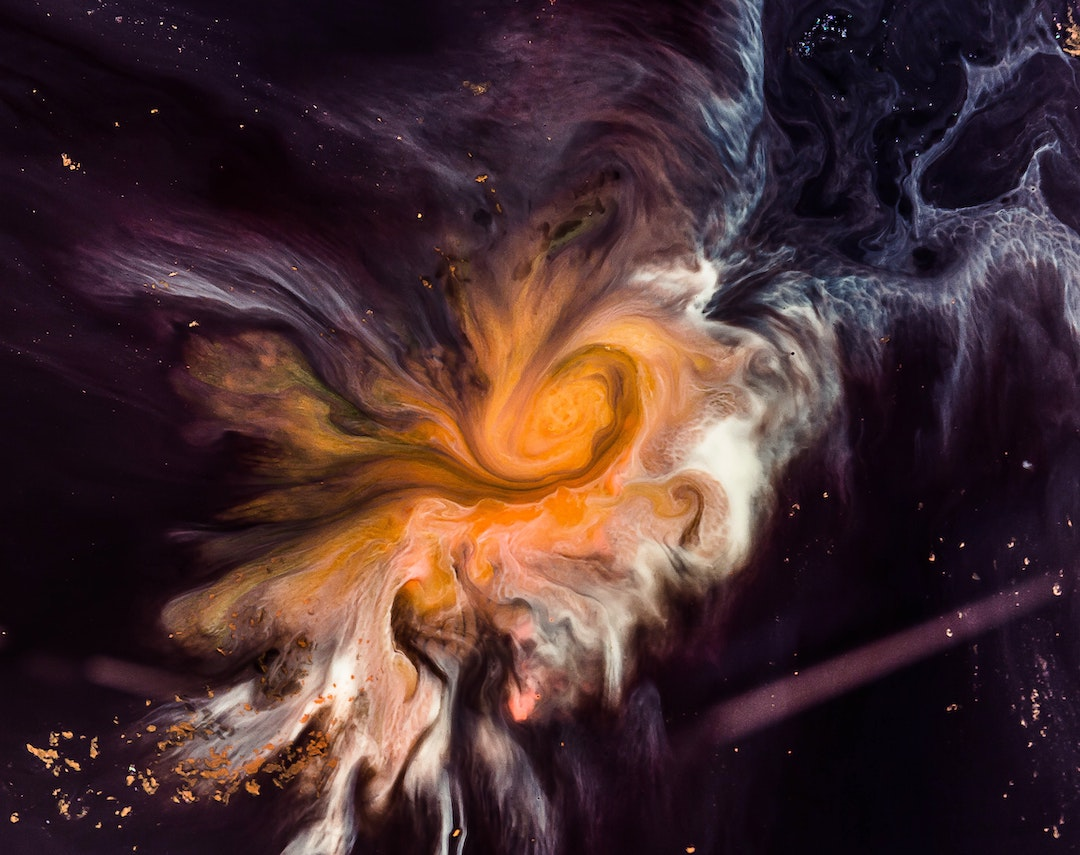



# Dataset Description

In this competition your task is to predict whether a passenger was transported to an alternate dimension during the Spaceship Titanic's collision with the spacetime anomaly. To help you make these predictions, you're given a set of personal records recovered from the ship's damaged computer system.

# File and Data Field Descriptions
train.csv - Personal records for about two-thirds (~8700) of the passengers, to be used as training data.

* PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.

* HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
* CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
* Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
* Destination - The planet the passenger will be debarking to.
* Age - The age of the passenger.
* VIP - Whether the passenger has paid for special VIP service during the voyage.
* RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
* Name - The first and last names of the passenger.
* Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

# Loading the dataset

In [1]:
import numpy as np # linear algebra
import pandas as pd 
import plotly.express as px


# Load the train data and test data
spaceship_file_path = '../input/spaceship-titanic/train.csv'
spaceship_data = pd.read_csv(spaceship_file_path)

test_file_path = '../input/spaceship-titanic/test.csv'
test_data = pd.read_csv(test_file_path)

display(spaceship_data.head())
display(test_data.head())

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


# Data Preview

In [2]:
spaceship_data.info

<bound method DataFrame.info of      PassengerId HomePlanet CryoSleep     Cabin    Destination   Age    VIP  \
0        0001_01     Europa     False     B/0/P    TRAPPIST-1e  39.0  False   
1        0002_01      Earth     False     F/0/S    TRAPPIST-1e  24.0  False   
2        0003_01     Europa     False     A/0/S    TRAPPIST-1e  58.0   True   
3        0003_02     Europa     False     A/0/S    TRAPPIST-1e  33.0  False   
4        0004_01      Earth     False     F/1/S    TRAPPIST-1e  16.0  False   
...          ...        ...       ...       ...            ...   ...    ...   
8688     9276_01     Europa     False    A/98/P    55 Cancri e  41.0   True   
8689     9278_01      Earth      True  G/1499/S  PSO J318.5-22  18.0  False   
8690     9279_01      Earth     False  G/1500/S    TRAPPIST-1e  26.0  False   
8691     9280_01     Europa     False   E/608/S    55 Cancri e  32.0  False   
8692     9280_02     Europa     False   E/608/S    TRAPPIST-1e  44.0  False   

      RoomService  

In [3]:
print("The number of variables in the original data:")
spaceship_data.columns
spaceship_data.dtypes

The number of variables in the original data:


PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

In [4]:
spaceship_data.isnull().sum()


PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [5]:
spaceship_data.duplicated().sum()

0

In [6]:
# percentage of the missing values(or NaN).
spaceship_data.isnull().sum().sum() / spaceship_data.shape[0]

0.2673415391694467

In [7]:
# Check the categorical variables
for col in spaceship_data.columns:
    if spaceship_data[col].dtype == object:
        print(col, "\b:")
        print(spaceship_data[col].value_counts(dropna = False))

PassengerId :
0001_01    1
6136_01    1
6141_01    1
6139_06    1
6139_05    1
          ..
3126_01    1
3124_03    1
3124_02    1
3124_01    1
9280_02    1
Name: PassengerId, Length: 8693, dtype: int64
HomePlanet :
Earth     4602
Europa    2131
Mars      1759
NaN        201
Name: HomePlanet, dtype: int64
CryoSleep :
False    5439
True     3037
NaN       217
Name: CryoSleep, dtype: int64
Cabin :
NaN        199
G/734/S      8
C/137/S      7
B/201/P      7
G/109/P      7
          ... 
G/556/P      1
E/231/S      1
G/545/S      1
G/543/S      1
C/178/S      1
Name: Cabin, Length: 6561, dtype: int64
Destination :
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
NaN               182
Name: Destination, dtype: int64
VIP :
False    8291
NaN       203
True      199
Name: VIP, dtype: int64
Name :
NaN                   200
Sus Coolez              2
Elaney Webstephrey      2
Dia Cartez              2
Grake Porki             2
                     ... 
Jamela Griffy       

In [8]:
# Check the numerical variables
for col in spaceship_data.columns:
    if spaceship_data[col].dtype != object:
        print(col, "\b:")
        print(spaceship_data[col].value_counts(dropna=False))

Age :
24.0    324
18.0    320
21.0    311
19.0    293
23.0    292
       ... 
72.0      4
78.0      3
79.0      3
76.0      2
77.0      2
Name: Age, Length: 81, dtype: int64
RoomService :
0.0       5577
NaN        181
1.0        117
2.0         79
3.0         61
          ... 
1612.0       1
2598.0       1
632.0        1
378.0        1
745.0        1
Name: RoomService, Length: 1274, dtype: int64
FoodCourt :
0.0       5456
NaN        183
1.0        116
2.0         75
3.0         53
          ... 
3846.0       1
5193.0       1
312.0        1
827.0        1
4688.0       1
Name: FoodCourt, Length: 1508, dtype: int64
ShoppingMall :
0.0       5587
NaN        208
1.0        153
2.0         80
3.0         59
          ... 
3627.0       1
2074.0       1
871.0        1
742.0        1
1872.0       1
Name: ShoppingMall, Length: 1116, dtype: int64
Spa :
0.0       5324
NaN        183
1.0        146
2.0        105
3.0         53
          ... 
273.0        1
2581.0       1
2948.0       1
3778.0 

# Exploratory Data Analysis



Let's have some basic understanding of how many passengers were transported

Text(0.5, 1.0, 'Transported distribution')

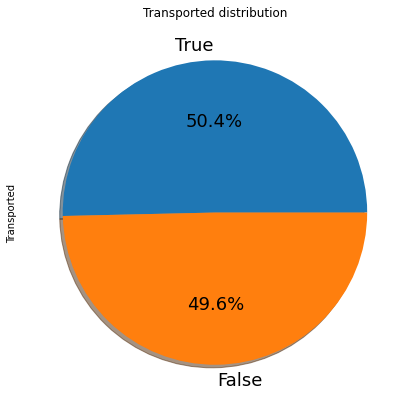

In [9]:


import matplotlib.pyplot as plt


# set the target
y = spaceship_data.Transported

# Pie Plot
plt.figure(figsize=(7,7))
y.value_counts().plot.pie(autopct='%2.1f%%', shadow=True, textprops={'fontsize':18}).set_title("Transported distribution")

2.The distribution of passengers in terms of homeplanet

In [10]:

HomePlanet_ct=spaceship_data.groupby(['HomePlanet']).count()
HomePlanet_ct

,PassengerId,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
HomePlanet,,,,,,,,,,,,,
Earth,4602,4488,4507,4503,4514,4487,4499,4505,4490,4503,4491,4496,4602
Europa,2131,2073,2070,2094,2085,2089,2095,2085,2078,2086,2094,2085,2131
Mars,1759,1716,1722,1717,1716,1716,1723,1721,1723,1723,1720,1718,1759


<AxesSubplot:title={'center':'Passengers distribution'}, ylabel='PassengerId'>

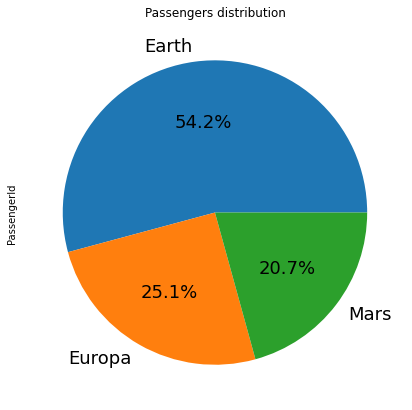

In [11]:
# Where are the passengers from?
plt.figure(figsize=(7,7))
HomePlanet_ct['PassengerId'].plot.pie(autopct='%2.1f%%',textprops={'fontsize':18},title="Passengers distribution")

About half the passengers are from the Earth.

In [12]:
# The distribution of age for the transported group and non-transported group
spaceship_data.dropna(axis=0,inplace=True)
px.box(spaceship_data, y="Age", color="Transported", points="all")

The median ages for the transported and non-tranported are very close(26, 28 respectively).

In [13]:
px.histogram(spaceship_data, x="Age", color="Transported", title="Histogram of Age")

In [14]:
spaceship_data['Age'].describe()

count    6606.000000
mean       28.894036
std        14.533429
min         0.000000
25%        19.000000
50%        27.000000
75%        38.000000
max        79.000000
Name: Age, dtype: float64

In [15]:
Destination_ct=spaceship_data.groupby(['Destination']).count()
Destination_ct

,PassengerId,HomePlanet,CryoSleep,Cabin,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
Destination,,,,,,,,,,,,,
55 Cancri e,1407,1407,1407,1407,1407,1407,1407,1407,1407,1407,1407,1407,1407
PSO J318.5-22,623,623,623,623,623,623,623,623,623,623,623,623,623
TRAPPIST-1e,4576,4576,4576,4576,4576,4576,4576,4576,4576,4576,4576,4576,4576


<AxesSubplot:title={'center':'Passengers distribution in terms of destination'}, ylabel='PassengerId'>

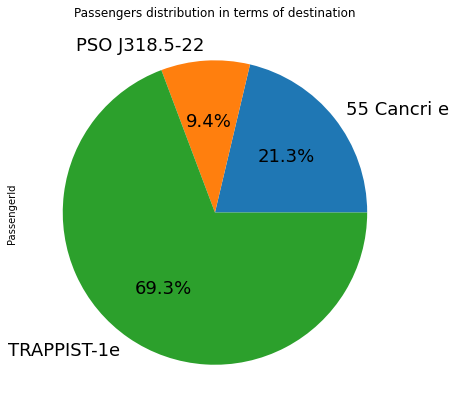

In [16]:
# Where is a passenger planning to go?

plt.figure(figsize=(7,7))
Destination_ct['PassengerId'].plot.pie(autopct='%2.1f%%',textprops={'fontsize':18},title="Passengers distribution in terms of destination")

In [17]:
px.histogram(spaceship_data, x="Destination",color="Transported")

In [18]:
Destination_tran_ct=spaceship_data.groupby(['Destination','Transported']).count()
Destination_tran_ct

PassengerId  HomePlanet  CryoSleep  Cabin   Age  \
Destination   Transported                                                    
55 Cancri e   False                531         531        531    531   531   
              True                 876         876        876    876   876   
PSO J318.5-22 False                308         308        308    308   308   
              True                 315         315        315    315   315   
TRAPPIST-1e   False               2440        2440       2440   2440  2440   
              True                2136        2136       2136   2136  2136   

                            VIP  RoomService  FoodCourt  ShoppingMall   Spa  \
Destination   Transported                                                     
55 Cancri e   False         531          531        531           531   531   
              True          876          876        876           876   876   
PSO J318.5-22 False         308          308        308           308   308   
              True          315          315        315           315   315   
TRAPPIST-1e   False        2440         2440       2440          2440  2440   
              True         2136         2136       2136          2136  2136   

                           VRDeck  Name  
Destination   Transported                
55 Cancri e   False           531   531  
              True            876   876  
PSO J318.5-22 False           308   308  
              True            315   315  
TRAPPIST-1e   False          2440  2440  
              True           2136  2136

There are a lot more passengers planning to go to TRAPPIST-1e than to 55 Cancri e and PSO J318.5-22. However, less than half of them are transported. The highest number of passengers being transported is from those whose destination is 55 Cancri e.

In [19]:
# These codes are from a Kaggler:ROLAND ERIKSSON
# The reason is that in my original codes 'Cabin' and 'PassengerId' were dropped, 
# Therefore we may lose some important information. In this new version, we
# used Roland's code to extract some information from 'Cabin' and 'PassenerId'.

# Split Cabin column
def split_cabin(df):
    newcols = df["Cabin"].str.split("/", expand=True)
    newcols.index = df.index
    df["Deck"] = newcols.iloc[:,0]
    df["Side"] = newcols.iloc[:,2]

# Add passenger group id and group size
def add_groupid(df):
    splitdf = df["PassengerId"].str.split("_", expand=True)
    df["GroupId"] = splitdf.iloc[:, 0]
    
def add_groupsize(df):
    grpsizes = df.groupby("GroupId").size()
    newcol = grpsizes[df["GroupId"]]
    newcol.index = df.index
    df["GroupSize"] = newcol.astype(float)   
    
# Combine all column manipulation
def preprocess(df):
    split_cabin(df)
    add_groupid(df)
    add_groupsize(df)
    
preprocess(spaceship_data)

In [20]:
spaceship_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,Side,GroupId,GroupSize
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,P,0001,1.0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,S,0002,1.0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,S,0003,2.0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,S,0003,2.0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,S,0004,1.0


In [21]:

px.histogram(spaceship_data, x="Deck",color="Transported")
#Observation: There are a lot of passengers from Deck G and F. But if you 
# look at the percentage, Deck B and C have higher percentage of passengers being transported(>50%).

In [22]:
px.histogram(spaceship_data, x="Side",color="Transported")

In [23]:
px.histogram(spaceship_data, x="GroupSize",color="Transported")


In [24]:
px.histogram(spaceship_data, x="VIP",color="Transported")


In [25]:
VIP_tran_ct=spaceship_data.groupby(['VIP','Transported']).count()
VIP_tran_ct

PassengerId  HomePlanet  CryoSleep  Cabin  Destination  \
VIP   Transported                                                           
False False               3177        3177       3177   3177         3177   
      True                3267        3267       3267   3267         3267   
True  False                102         102        102    102          102   
      True                  60          60         60     60           60   

                    Age  RoomService  FoodCourt  ShoppingMall   Spa  VRDeck  \
VIP   Transported                                                             
False False        3177         3177       3177          3177  3177    3177   
      True         3267         3267       3267          3267  3267    3267   
True  False         102          102        102           102   102     102   
      True           60           60         60            60    60      60   

                   Name  Deck  Side  GroupId  GroupSize  
VIP   Transported                                        
False False        3177  3177  3177     3177       3177  
      True         3267  3267  3267     3267       3267  
True  False         102   102   102      102        102  
      True           60    60    60       60         60

About 50% of the passengers are transported in non-VIP group, while about 1/3 of the passengers are transported in VIP group.

In [26]:
px.histogram(spaceship_data, x="CryoSleep",color="Transported")


In [27]:
CryoSleep_tran_ct=spaceship_data.groupby(['CryoSleep','Transported']).count()
CryoSleep_tran_ct

PassengerId  HomePlanet  Cabin  Destination   Age  \
CryoSleep Transported                                                      
False     False               2852        2852   2852         2852  2852   
          True                1422        1422   1422         1422  1422   
True      False                427         427    427          427   427   
          True                1905        1905   1905         1905  1905   

                        VIP  RoomService  FoodCourt  ShoppingMall   Spa  \
CryoSleep Transported                                                     
False     False        2852         2852       2852          2852  2852   
          True         1422         1422       1422          1422  1422   
True      False         427          427        427           427   427   
          True         1905         1905       1905          1905  1905   

                       VRDeck  Name  Deck  Side  GroupId  GroupSize  
CryoSleep Transported                                                
False     False          2852  2852  2852  2852     2852       2852  
          True           1422  1422  1422  1422     1422       1422  
True      False           427   427   427   427      427        427  
          True           1905  1905  1905  1905     1905       1905

About 2/3 are transported in CryoSleep group, in contrast to about 1/4 in non-CryoSleep group. If you are Crypsleeping, you are more likely being transported.

Conclusions:

1. There are ~26% missing values. For the purpose of machine learning, simply dropping those missing values will not be ideal. How to handle missing numerical and categorical values is refered in another notebook.

2. Outliers are not found.

3. Most of the passengers are from the Earth. Most of the passengers plan to go to TRAPPIST 1e.

4. If a passenger is CryoSleeping, he/she will be likely tranported.

5. There are more people from non-VIP group being transported than frm VIP group.

6. Most of the passengers stay in Deck G & F, but more people from Deck B & C are transported.